In [1]:
import pandas as pd
import numpy as np
import random as rd
from sklearn.decomposition import PCA
from sklearn import preprocessing
import matplotlib.pyplot as plt
#implementing K-means rom scratch using PCA code for dimensionality reduction 

In [2]:

path = r'C:\Users\samik\Downloads\weatherAUS (3).zip'
data = pd.read_csv(path)
data = data.drop(columns=['Date', 'Location', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow'])
column_mean = data['Rainfall'].replace(0, pd.NA).mean()
data['Rainfall'] = data['Rainfall'].replace(0, column_mean)
data = data.fillna(data.mean())
data #processed data

,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
0,13.4,22.900000,0.600000,44.00000,20.0,24.0,71.0,22.0,1007.7,1007.1,8.000000,4.50993,16.9,21.8
1,7.4,25.100000,6.567425,44.00000,4.0,22.0,44.0,25.0,1010.6,1007.8,4.447461,4.50993,17.2,24.3
2,12.9,25.700000,6.567425,46.00000,19.0,26.0,38.0,30.0,1007.6,1008.7,4.447461,2.00000,21.0,23.2
3,9.2,28.000000,6.567425,24.00000,11.0,9.0,45.0,16.0,1017.6,1012.8,4.447461,4.50993,18.1,26.5
4,17.5,32.300000,1.000000,41.00000,7.0,20.0,82.0,33.0,1010.8,1006.0,7.000000,8.00000,17.8,29.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2.8,23.400000,6.567425,31.00000,13.0,11.0,51.0,24.0,1024.6,1020.3,4.447461,4.50993,10.1,22.4
145456,3.6,25.300000,6.567425,22.00000,13.0,9.0,56.0,21.0,1023.5,1019.1,4.447461,4.50993,10.9,24.5
145457,5.4,26.900000,6.567425,37.00000,9.0,9.0,53.0,24.0,1021.0,1016.8,4.447461,4.50993,12.5,26.1
145458,7.8,27.000000,6.567425,28.00000,13.0,7.0,51.0,24.0,1019.4,1016.5,3.000000,2.00000,15.1,26.0


In [3]:
scaled_data = preprocessing.scale(data) # Standardize features by removing the mean and scaling to unit variance
scaled_data

array([[ 1.89446615e-01, -4.53363105e-02, -7.66839815e-01, ...,
        -8.48734694e-16, -1.40531282e-02,  1.70232282e-02],
       [-7.53100728e-01,  2.65043084e-01,  4.69093830e-14, ...,
        -8.48734694e-16,  3.24642790e-02,  3.81984952e-01],
       [ 1.10901003e-01,  3.49692009e-01,  4.69093830e-14, ...,
        -1.19923244e+00,  6.21684769e-01,  2.21401794e-01],
       ...,
       [-1.06728318e+00,  5.18989861e-01,  4.69093830e-14, ...,
        -8.48734694e-16, -6.96308433e-01,  6.44757393e-01],
       [-6.90264238e-01,  5.33098015e-01,  4.69093830e-14, ...,
        -1.19923244e+00, -2.93157571e-01,  6.30158924e-01],
       [ 4.25083451e-01, -5.01222327e-16,  4.69093830e-14, ...,
         1.66753850e+00, -3.08663373e-01, -1.14362992e-01]])

In [4]:
#reducing dimension using PCA
pca = PCA()
pca.fit(scaled_data)
pca_data = pca.transform(scaled_data)
per_var = np.round(pca.explained_variance_ratio_ * 100, decimals=1)
labels = ['PC' + str(x) for x in range(1, len(per_var) + 1)]
pca_data

array([[ 1.09703985,  1.339344  ,  0.30293292, ...,  0.30680865,
        -0.01365257, -0.10281917],
       [ 1.22248686, -0.27937698,  0.45698626, ...,  0.0968372 ,
        -0.03337572,  0.09435003],
       [ 2.28781384,  0.21979006,  1.36188306, ...,  0.30028477,
         0.26011404,  0.03956706],
       ...,
       [-0.12478978, -1.75870388,  0.21258477, ..., -0.28406961,
         0.09785432,  0.06269129],
       [ 0.38634404, -2.48362473,  0.38569478, ..., -0.09189787,
         0.14107545,  0.04625148],
       [-0.28686572,  0.62494415, -0.51617346, ..., -0.25839498,
         0.06174311, -0.16379845]])

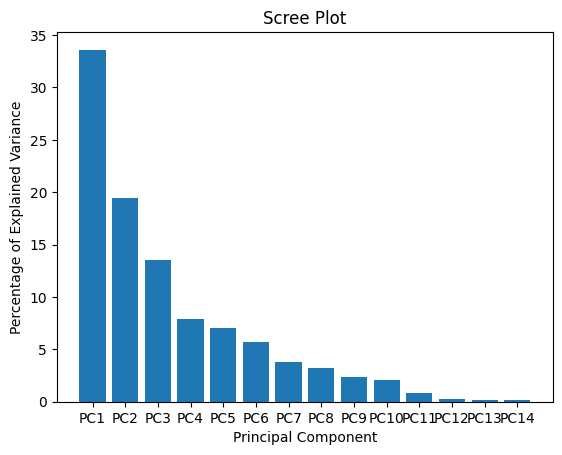

In [5]:
plt.bar(x=range(1, len(per_var) + 1), height=per_var, tick_label=labels)
plt.ylabel('Percentage of Explained Variance')
plt.xlabel('Principal Component')
plt.title('Scree Plot')
plt.show()

In [6]:
pca_df = pd.DataFrame(pca_data, index=data.index, columns=labels)
pca_2d = pca_df[['PC1', 'PC2']]
pca_2d_np=pca_2d.values
pca_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14
0,1.097040,1.339344,0.302933,-0.767002,-1.336124,-0.891536,-0.699525,1.417547,0.306838,-0.577626,0.702805,0.306809,-0.013653,-0.102819
1,1.222487,-0.279377,0.456986,-1.557899,-0.533731,-1.371361,-0.968393,-0.407700,-0.753326,-0.022324,-0.115759,0.096837,-0.033376,0.094350
2,2.287814,0.219790,1.361883,-1.021531,-0.170289,-0.409617,-0.086095,0.782291,-0.993262,-0.260542,0.119055,0.300285,0.260114,0.039567
3,0.915354,-1.932092,-0.327315,-0.580618,-0.414864,-1.767179,0.266878,0.333051,-0.086014,-0.508808,-0.057851,0.053232,-0.120107,-0.124740
4,1.635833,0.910632,-1.802116,-0.366112,-1.521414,-0.974765,-1.170729,-0.334079,1.068422,-0.361930,0.273688,-0.447352,0.043501,-0.172724
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,-1.095943,-1.925437,0.797953,0.049188,-0.175743,-1.740970,-0.009638,0.210202,0.179461,-0.146010,-0.408011,-0.250726,0.064194,-0.017263
145456,-0.857428,-2.243677,0.223952,-0.113955,-0.195989,-1.736964,0.099879,0.400875,0.433510,-0.638967,-0.410085,-0.231097,0.082535,-0.015860
145457,-0.124790,-1.758704,0.212585,-0.378750,-0.255669,-1.654171,-0.266649,0.084737,0.377373,0.341377,-0.453625,-0.284070,0.097854,0.062691
145458,0.386344,-2.483625,0.385695,-0.747152,0.153719,-0.820858,0.413792,0.726137,0.165452,-0.030600,-0.260868,-0.091898,0.141075,0.046251


In [7]:
#implementing K-means
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

In [8]:
def initialize_centroids(k, data):
    return data.sample(n=k).values

In [9]:
def assign_clusters(centroids, data):
    clusters = []
    for i in range(len(data)):
        distances = [euclidean_distance(data.iloc[i], centroid) for centroid in centroids]
        clusters.append(np.argmin(distances))
    return np.array(clusters)

In [10]:
def update_centroids(k, clusters, data):
    new_centroids = []
    for i in range(k):
        cluster_points = data[clusters == i]
        if len(cluster_points) > 0:
            new_centroids.append(np.mean(cluster_points, axis=0))
        else:
            new_centroids.append(np.zeros(data.shape[1]))
    return np.array(new_centroids)

In [ ]:

def kmeans(data, k, max_iters=100, tol=1e-4):
    centroids = initialize_centroids(k, data)
    for _ in range(max_iters):
        clusters = assign_clusters(centroids, data)
        new_centroids = update_centroids(k, clusters, data)
        
        if np.all(np.abs(new_centroids - centroids) < tol):
            break
        centroids = new_centroids
    return clusters, centroids


In [25]:
k = 2
clusters, centroids = kmeans(pca_2d, k,max_iters=1)
clusters

array([1, 1, 1, ..., 1, 1, 1])

In [27]:
pca_df['Cluster'] = clusters
pca_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,Cluster
0,1.097040,1.339344,0.302933,-0.767002,-1.336124,-0.891536,-0.699525,1.417547,0.306838,-0.577626,0.702805,0.306809,-0.013653,-0.102819,1
1,1.222487,-0.279377,0.456986,-1.557899,-0.533731,-1.371361,-0.968393,-0.407700,-0.753326,-0.022324,-0.115759,0.096837,-0.033376,0.094350,1
2,2.287814,0.219790,1.361883,-1.021531,-0.170289,-0.409617,-0.086095,0.782291,-0.993262,-0.260542,0.119055,0.300285,0.260114,0.039567,1
3,0.915354,-1.932092,-0.327315,-0.580618,-0.414864,-1.767179,0.266878,0.333051,-0.086014,-0.508808,-0.057851,0.053232,-0.120107,-0.124740,1
4,1.635833,0.910632,-1.802116,-0.366112,-1.521414,-0.974765,-1.170729,-0.334079,1.068422,-0.361930,0.273688,-0.447352,0.043501,-0.172724,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,-1.095943,-1.925437,0.797953,0.049188,-0.175743,-1.740970,-0.009638,0.210202,0.179461,-0.146010,-0.408011,-0.250726,0.064194,-0.017263,1
145456,-0.857428,-2.243677,0.223952,-0.113955,-0.195989,-1.736964,0.099879,0.400875,0.433510,-0.638967,-0.410085,-0.231097,0.082535,-0.015860,1
145457,-0.124790,-1.758704,0.212585,-0.378750,-0.255669,-1.654171,-0.266649,0.084737,0.377373,0.341377,-0.453625,-0.284070,0.097854,0.062691,1
145458,0.386344,-2.483625,0.385695,-0.747152,0.153719,-0.820858,0.413792,0.726137,0.165452,-0.030600,-0.260868,-0.091898,0.141075,0.046251,1


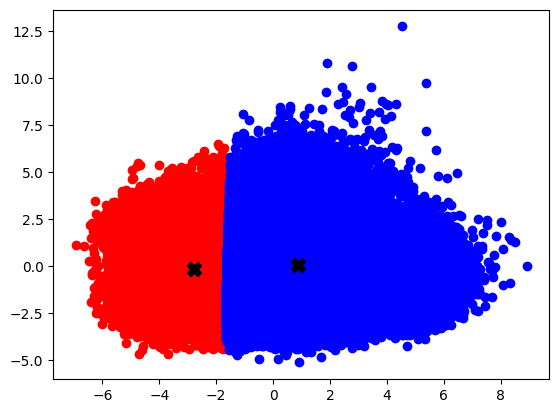

In [28]:
colors = ['red', 'blue', 'green']
for i in range(k):
    
    clustered_data = pca_df[pca_df['Cluster'] == i]
    plt.scatter(clustered_data['PC1'], clustered_data['PC2'], color=colors[i], label=f'Cluster {i}')
    plt.scatter(centroids[:, 0], centroids[:, 1], color='black', marker='X', s=100, label='Centroids')
    